In [ ]:
# Ensure addplot data matches the same index range as the main data
# import mplfinance as mpl
# aapl_subset = aapl.iloc[:250]
# addplots = [
#     mpf.make_addplot(aapl_subset['sma_50'], color='blue', label='SMA 50'),
#     mpf.make_addplot(aapl_subset['sma_200'], color='red', label='SMA 200'),
#     mpf.make_addplot(aapl_subset['ema_20'], color='green', label='EMA 20'),
# ]

# mpf.plot(aapl_subset, type='candle', style='charles', volume=False, figsize=(12,6), addplot=addplots, title="AAPL - Price & Trend Indicators")

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = "../data/processed/panel_preprocessed.parquet"

df = pd.read_parquet(DATA_PATH)

In [ ]:
print(df.shape)
print(df[["date", "ticker"]].duplicated().sum())

(27650, 37)
(27650, 37)
0


In [4]:
macro_cols = ["CPIAUCSL", "FEDFUNDS", "GDP"]
df[macro_cols].isna().mean()

CPIAUCSL    0.003617
FEDFUNDS    0.000000
GDP         0.014105
dtype: float64

In [5]:
df[[
    "net_margin", "roe", "revenue_growth_qoq",
    "debt_to_equity"
]].describe(percentiles=[.01, .99])


,net_margin,roe,revenue_growth_qoq,debt_to_equity
count,27650.000000,27650.000000,27650.000000,27209.000000
mean,0.185253,0.073357,0.048286,0.716908
std,0.152105,0.091390,0.160517,0.698415
min,-0.515706,-0.266282,-0.392443,0.004116
1%,-0.234413,-0.170333,-0.312161,0.010384
50%,0.200593,0.062650,0.041032,0.455953
99%,0.537704,0.405815,0.657968,2.740404
max,1.000000,0.521597,0.809572,3.556831


In [6]:
df.isna().mean().sort_values(ascending=False).head(10)

sma_200           0.072333
sma_50            0.018083
price_sma_50      0.018083
debt_to_equity    0.015949
GDP               0.014105
ret_21d           0.007957
volatility_20d    0.007595
rsi_14            0.005425
CPIAUCSL          0.003617
ret_5d            0.002170
dtype: float64

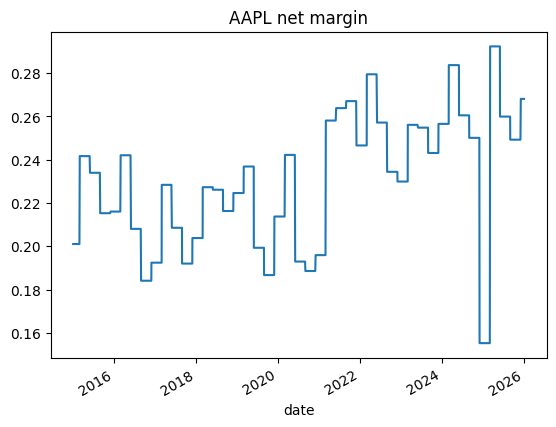

In [7]:
import matplotlib.pyplot as plt

df[df.ticker == "AAPL"].set_index("date")["net_margin"].plot(title="AAPL net margin")
plt.show()
